Cantilever subjected to a tip load and moment. 

In [1]:

# The frame is modeled with different geometric transformations, 
# and the convergence of the solution is analyzed in terms of drift and number of iterations.
#
import os
import xara

# External libraries
import numpy as np
import matplotlib.pyplot as plt
from xara.post import PlotConvergenceRate



def create_cantilever(shape,
                      material,
                      L,
                      element,
                      transform="Corotational02",
                      shear=1,
                      ne=10):


    nen = 2
    nn = ne*(nen-1)+1

    model = xara.Model(ndm=3, ndf=6)

    sec = 1


    model.section("ElasticFrame", sec, **material, **shape)

    model.geomTransf(transform, 1, (0,0,1))

    for i,x in enumerate(np.linspace(0, L, nn)):
        model.node(i, (x,0,0))


    for i in range(ne):
        start = i * (nen - 1)
        nodes = tuple(range(start, start + nen))
        model.element(element, i+1, nodes, section=sec, transform=1, shear=shear)


    model.fix(0,     (1,1,1,  1,1,1))
    model.fix(nn-1,  (0,0,0,  0,0,0))
    return model


def analyze(model, Mmax, Fmax, nsteps=1, post=None):

    end = len(model.getNodeTags()) - 1
    #
    # Apply loading
    #
    model.pattern("Plain", 1, "Linear")
    model.load(end, (0,0,Fmax,  0,0,Mmax), pattern=1)

    model.system('Umfpack')
    model.integrator("LoadControl", 1/nsteps)
    # model.integrator("MinUnbalDispNorm", 10/nsteps, 5,  10/nsteps/50, 20/nsteps)
    model.test("Residual", 1e-8, 55, 0) #50 #20
    model.algorithm("Newton")
    model.analysis("Static")

    ux = []
    uy = []
    P  = []
    ni = [5]
    L  = model.nodeCoord(end, 1)

    ux.append(1+model.nodeDisp(end, 1)/L)
    uy.append(  model.nodeDisp(end, 2)/L)
    P.append(model.getTime())


    while model.getTime() < 1.0:
        if model.analyze(1) != 0:
            print(f"Failed at time = {model.getTime()}")
            break
        ni.append(model.numIter())
        ux.append(1+model.nodeDisp(end, 1)/L)
        uy.append(  model.nodeDisp(end, 2)/L)
        P.append(model.getTime())

        if post is not None:
            for p in post:
                p.update(model)


    print(sum(ni)/len(ni), np.array(model.nodeDisp(end))[:3]) # + model.nodeCoord(end))
    return ux, uy, P, ni


In [2]:

length = 10.0

material = dict(
    E = 1e4,
    G = 1e4
)

shape = dict(
    A   = 1,
    Ay  = 1,
    Az  = 1,
    Iy  = 1e-2,
    Iz  = 1e-2,
    J   = 1e-2
)

M0 = 20*np.pi # 2 pi EI /L

analyze(create_cantilever(
                    shape,
                    material,
                    length,
                    ne=10,
                    shear=1,
                    element = "ExactFrame",
                    transform="Linear"),
            Mmax=M0/8, Fmax=1/16, nsteps=1)




4.5 [-0.99618713  3.7285453   0.19507128]


([1.0, 0.9003812872453015], [0.0, 0.372854530126929], [0.0, 1.0], [5, 4])

In [3]:

Transforms = [
    "Corotational01",
    "Corotational02",
    "Corotational03",
    # "Corotational04",
    # "Corotational05",
#       "Corotational06",
]

for transform in Transforms: #
    print(f"Transform: {transform}")
    model = create_cantilever(shape,
                            material,
                            length,
                            ne=10,
                            element = os.environ.get("Element", "ForceFrame"),
                            transform=transform)

    analyze(model, Mmax=M0/8, Fmax=1/16, nsteps=1)



Transform: Corotational01
6.0 [-0.99620074  3.72853021  0.19595805]
Transform: Corotational02
6.0 [-0.99619153  3.72852156  0.19577572]
Transform: Corotational03
6.0 [-0.99619176  3.72852195  0.19577602]



Looping
-------

6.232142857142857 [-9.97743218e+00  2.73529269e-03 -3.22264428e-01]
Transform: Corotational01
   FAILURE :: Iter:    55, Norm:      242381, Norm deltaX:      39.951
Failed at time = 0.15000000000000008
4.508196721311475 [-11.93501208   1.43350849  -0.95488376]
Transform: Corotational02
4.129353233830845 [-10.36601128   0.14716412   0.42531269]
Transform: Corotational03
4.129353233830845 [-10.08205372   1.0009136    3.90992359]
Transform: Spherical
   FAILURE :: Iter:    55, Norm:      260044, Norm deltaX:     48.7886
Failed at time = 0.1900000000000001
4.51948051948052 [-1.00543865e+01  4.27768191e-03 -1.23530397e+00]


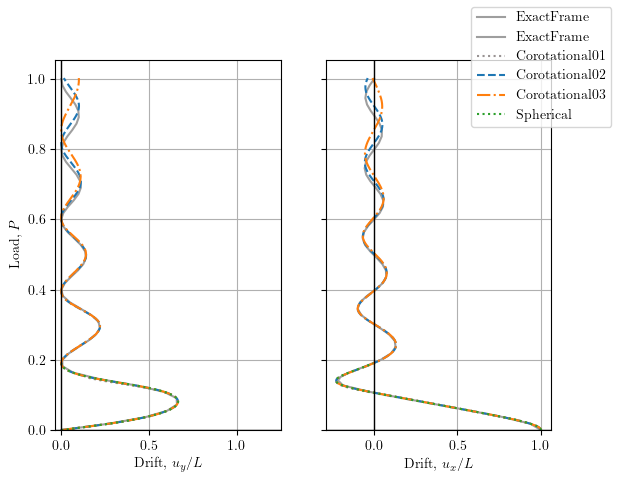

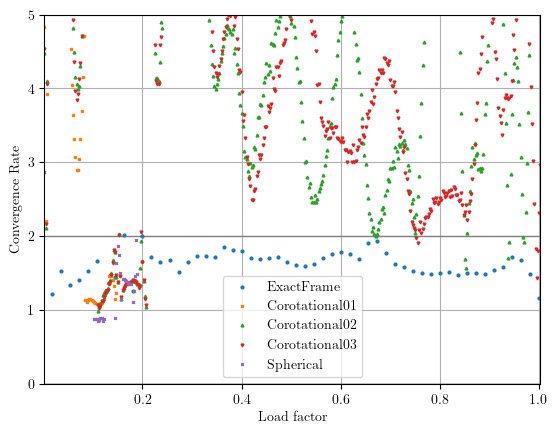

In [4]:

#
#
#
print("\nLooping\n-------\n")
markers = iter([":", "--", "-."]*2)
colors  = iter(["#999393", "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"])
fig, ax = plt.subplots(1,2, sharey=True)


color = "#9E9E9E"

post = [
    PlotConvergenceRate(ci=95, x_mode="time")
]

post[-1].reset(label="ExactFrame")
ux, uy, P,ni = analyze(create_cantilever(
                    shape,
                    material,
                    length,
                    ne=10,
                    shear=1,
                    element = "ExactFrame",
                    transform="Spherical"),
            post=post,
            Mmax=5.0*M0, Fmax=25, nsteps=55)
post[-1].draw()
ax[0].plot(uy, P, "-", color=color, label="ExactFrame")
ax[1].plot(ux, P, "-", color=color, label="ExactFrame")


for transform in  [*Transforms, "Spherical"]: # "Linear",
    element = "ForceFrame" if "Coro" in transform else "CosseratFrame"
    print(f"Transform: {transform}")
    model = create_cantilever(shape,
                            material,
                            length,
                            ne=10,
                            element = element,
                            transform=transform)
    post[-1].reset(label=transform)
    ux, uy, P, ni = analyze(model, Mmax=5.0*M0, Fmax=25, nsteps=400, post=post)
    post[-1].draw()
    marker = next(markers)
    color  = next(colors)
    ax[0].plot(uy, P, marker, color=color)
    ax[1].plot(ux, P, marker, color=color, label=transform)

post[-1].finalize()

ax[0].set_xlabel(r"Drift, $u_y/L$")
ax[1].set_xlabel(r"Drift, $u_x/L$")
ax[0].set_ylabel("Load, $P$")
ax[0].set_xlim([None, 1.25])
for axi in ax:
    axi.grid("on")
    # axi.set_xlim([None, 1.25])
    axi.set_ylim([0, None])
    axi.axvline(0, color='black', linestyle='-', linewidth=1)
    axi.axhline(0, color='black', linestyle='-', linewidth=1)
axi.figure.legend()

